#Task 11: Vision Transformer (ViT) Patch Projection and Multi-Head Self-Attention from Scratch
#Objective:
Adapt Transformer architectures to visual data by constructing spatial patch
extraction modules and multi-head representation attention matrices.
#Required Tech Stack:
 PyTorch, Einops, Transformers.
#Task Description:
Students will build a Vision Transformer block from first principles. They
must write a custom linear patch projection layer, append learnable class and positional
embeddings, implement multi-head self-attention using Einstein summation syntax via
einops, and visualize attention maps on high-resolution images.

Install & Import Libraries

In [1]:
!pip -q install einops transformers

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from einops import rearrange

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Load Dataset

In [2]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

100%|██████████| 170M/170M [12:29<00:00, 228kB/s]


Patch Embedding

In [3]:
class PatchEmbedding(nn.Module):

    def __init__(self,
                 img_size=32,
                 patch_size=4,
                 in_channels=3,
                 embed_dim=128):

        super().__init__()

        self.patch_size = patch_size

        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Linear(
            patch_size * patch_size * in_channels,
            embed_dim
        )

    def forward(self,x):

        patches = rearrange(
            x,
            "b c (h p1) (w p2) -> b (h w) (p1 p2 c)",
            p1=self.patch_size,
            p2=self.patch_size
        )

        return self.proj(patches)

Multi-Head Self-Attention

In [4]:
class MultiHeadAttention(nn.Module):

    def __init__(self,
                 embed_dim=128,
                 heads=4):

        super().__init__()

        self.heads = heads

        self.scale = (embed_dim // heads) ** -0.5

        self.qkv = nn.Linear(
            embed_dim,
            embed_dim * 3
        )

        self.proj = nn.Linear(
            embed_dim,
            embed_dim
        )

    def forward(self,x):

        B,N,D = x.shape

        qkv = self.qkv(x)

        q,k,v = qkv.chunk(3,dim=-1)

        q = rearrange(q,"b n (h d)->b h n d",h=self.heads)
        k = rearrange(k,"b n (h d)->b h n d",h=self.heads)
        v = rearrange(v,"b n (h d)->b h n d",h=self.heads)

        attention = torch.softmax(
            (q @ k.transpose(-2,-1))*self.scale,
            dim=-1
        )

        out = attention @ v

        out = rearrange(
            out,
            "b h n d -> b n (h d)"
        )

        return self.proj(out), attention

Transformer Encoder

In [5]:
class TransformerBlock(nn.Module):

    def __init__(self, embed_dim=128):

        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attn = MultiHeadAttention(embed_dim)

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim,256),
            nn.GELU(),
            nn.Linear(256,embed_dim)
        )

    def forward(self,x):

        out,attention = self.attn(self.norm1(x))

        x = x + out

        x = x + self.mlp(self.norm2(x))

        return x,attention

Vision Transformer

In [6]:
class VisionTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.patch = PatchEmbedding()

        self.cls = nn.Parameter(torch.randn(1,1,128))

        self.pos = nn.Parameter(torch.randn(1,65,128))

        self.encoder = TransformerBlock()

        self.head = nn.Linear(128,10)

    def forward(self,x):

        x = self.patch(x)

        B = x.size(0)

        cls = self.cls.expand(B,-1,-1)

        x = torch.cat([cls,x],dim=1)

        x = x + self.pos

        x,attention = self.encoder(x)

        logits = self.head(x[:,0])

        return logits,attention

Training

In [7]:
model = VisionTransformer().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

losses = []

for epoch in range(5):

    total = 0

    model.train()

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs,_ = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        total += loss.item()

    losses.append(total)

    print(f"Epoch {epoch+1}: {total:.4f}")

Epoch 1: 1475.2519
Epoch 2: 1283.6690
Epoch 3: 1201.0246
Epoch 4: 1147.7917
Epoch 5: 1112.9037


Test Accuracy

In [8]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs,_ = model(images)

        pred = outputs.argmax(1)

        correct += (pred == labels).sum().item()
        total += labels.size(0)

print("Training Accuracy:",100*correct/total)

Training Accuracy: 49.192


Visualize Attention Map

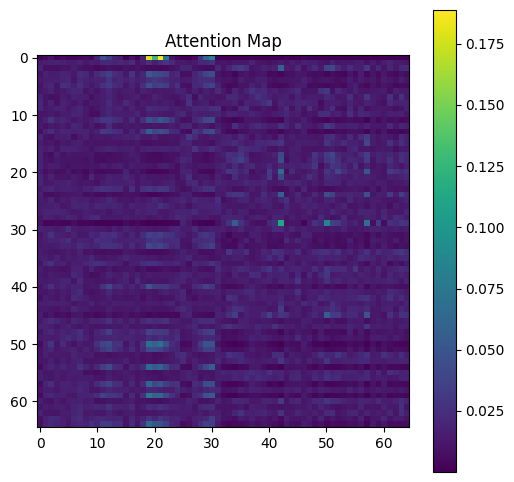

In [9]:
images,_ = next(iter(train_loader))

images = images.to(device)

_,attention = model(images)

plt.figure(figsize=(6,6))

plt.imshow(
    attention[0,0].detach().cpu().numpy(),
    cmap="viridis"
)

plt.title("Attention Map")

plt.colorbar()

plt.show()